# Counting and Cardinality - Images

## Setup

Set up `sys.path` to work while within a subfolder.

In [1]:
import sys
sys.path.append("../..")

Enable this if working within VSCode.

In [2]:
import os

if not os.environ.get("NOTEBOOK_PATH"):
    os.environ["NOTEBOOK_PATH"] = "notebooks/part-1/counting.ipynb"

Manim-related imports.

In [3]:
from manim import *
from manim_utils import *

Set up the image generation cell magic.

In [4]:
%load_ext magics.generate_image

Loaded extension.


## Scenes

### The Counting of Five Items
The dialogue at the start of the chapter.

Common constants for the scenes.

In [5]:
ITEM_CLASSES = [Circle, Star, Triangle, Square, RegularPolygon]
ITEM_COLOURS = [RED, BLUE, GREEN, ORANGE, GRAY]
ITEM_RADIUS = 0.75
ITEM_SPACING = 2

LABEL_SHIFT = 1.25  # Downwards

Helper functions to set up items and labels.

In [6]:
def create_items() -> VGroup:
    items = []
    for i in range(5):
        cls = ITEM_CLASSES[i]
        if cls == Circle:
            item = cls(radius=ITEM_RADIUS)
        elif cls == Square:
            item = cls(side_length=ITEM_RADIUS * 2)
        elif cls == Star:
            item = cls(outer_radius=ITEM_RADIUS)
        elif cls == Triangle or cls == RegularPolygon:
            if cls == Triangle:
                item = RegularPolygon(n=3)
            else:
                item = RegularPolygon(n=6)
            item = cls().scale(ITEM_RADIUS)
        else:
            raise ValueError(f"Unknown class {cls}")
        item.set_color(ITEM_COLOURS[i])
        item.set_fill(ITEM_COLOURS[i], opacity=0.25)
        item.move_to((i-2) * ITEM_SPACING * RIGHT)
        items.append(item)

    return VGroup(*items)

In [7]:
def create_labels(items: VGroup, labels: list[tuple[int, ...]]) -> VGroup:
    assert len(labels) == 5

    label_objects = []
    for i, item in enumerate(items):
        the_labels = labels[i]
        if len(the_labels) == 0:
            continue
            
        label = Text(f"{', '.join([str(x) for x in the_labels])}", color=BLACK)
        label.move_to(item)
        label.shift(LABEL_SHIFT * DOWN)
        label_objects.append(label)

    return VGroup(*label_objects)

Just the items.

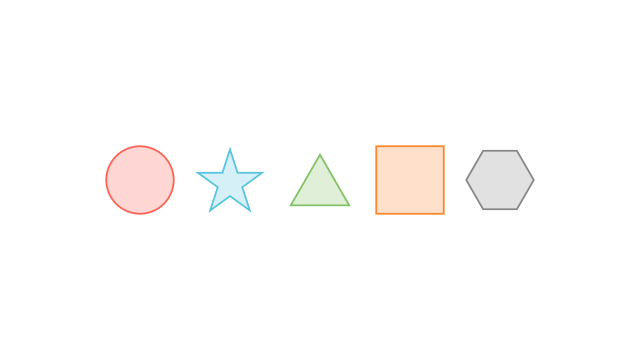

In [8]:
%%generate_image five-count_items-only CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        items = create_items()
        self.add(items)

Non-injective, non-surjective counting.

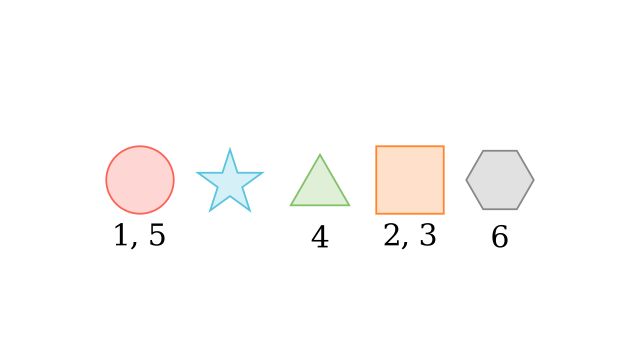

In [9]:
%%generate_image five-count_noninj-nonsurj CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (1,5),
            (),
            (4,),
            (2,3),
            (6,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)

Injective, non-surjective counting.

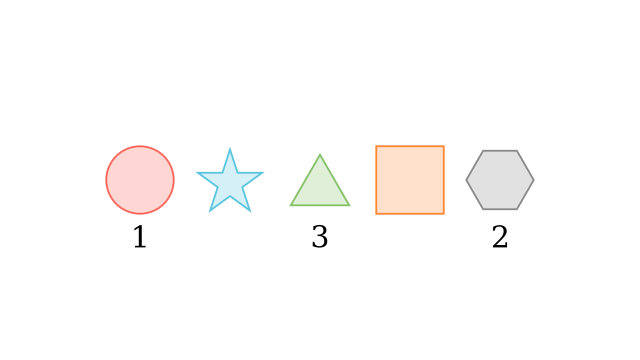

In [10]:
%%generate_image five-count_yesinj-nonsurj CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (1,),
            (),
            (3,),
            (),
            (2,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)

Disregarding stars.

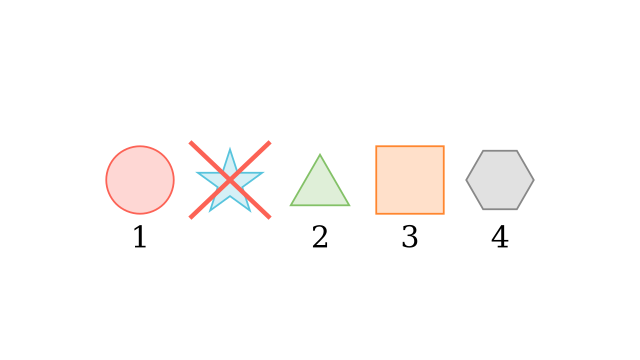

In [11]:
%%generate_image five-count_no-star CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (1,),
            (),
            (2,),
            (3,),
            (4,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)
        
        # Cross out the star
        cross = Cross(items[1], stroke_width=10.0, scale_factor=1.25)  # Which is the star
        self.add(cross)


Non-injective, surjective counting.

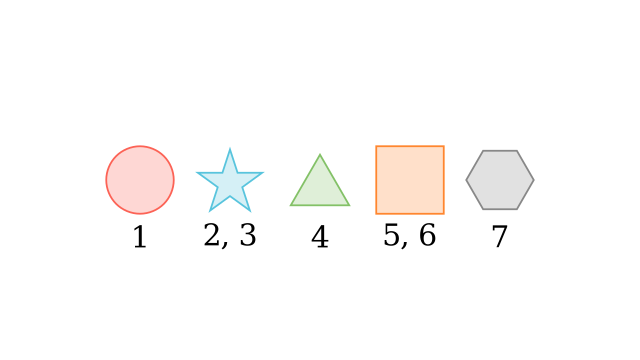

In [12]:
%%generate_image five-count_noninj-yessurj CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (1,),
            (2,3),
            (4,),
            (5,6),
            (7,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)

Injective, surjective counting.

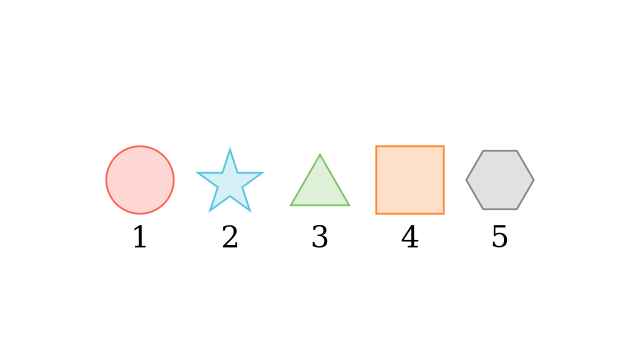

In [13]:
%%generate_image five-count_yesinj-yessurj CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (1,),
            (2,),
            (3,),
            (4,),
            (5,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)

### Equinumerous Sets

The function $f$ where
$$
    f = \{(a, w), (b, x), (c, y), (d, z)\}.
$$

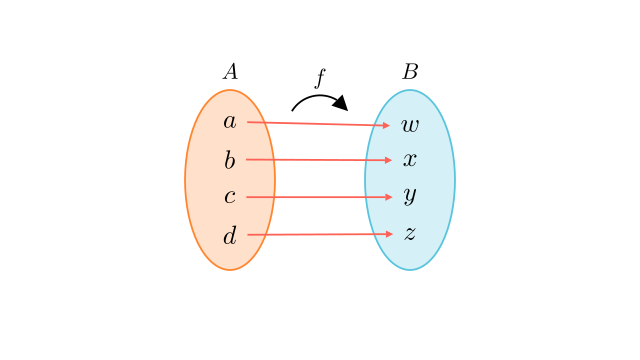

In [14]:
%%generate_image equinumerous-sets_f FunctionDiagram

A_FONT_SIZE = 56  # TeX font size
A_COLOUR = ORANGE
B_FONT_SIZE = 56
B_COLOUR = BLUE

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a.shift(2 * LEFT)
        
        ellipse_b = Ellipse(width=2, height=4, color=B_COLOUR)
        ellipse_b.set_fill(B_COLOUR, opacity=0.25)
        ellipse_b.shift(2 * RIGHT)

        self.add(ellipse_a, ellipse_b)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)

        self.add(label_a, label_b)

        # Add function label
        f_label = MathTex("f", color=BLACK).move_to(2.25*UP)
        f_label.add(
            CurvedArrow(
                f_label.get_left() + LEFT * 0.5,
                f_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        self.add(f_label)

        # Create elements for sets
        elements_a = ["a", "b", "c", "d"]
        elements_b = ["w", "x", "y", "z"]

        elements_a = [MathTex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [MathTex(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.5).move_to(ellipse_b)

        self.add(elements_a, elements_b)
        
        # Create arrows
        arrow_links = [(i,i) for i in range(4)]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))

The function $g$ where
$$
    g = \{(a, z), (b, x), (c, w), (d, y)\}.
$$

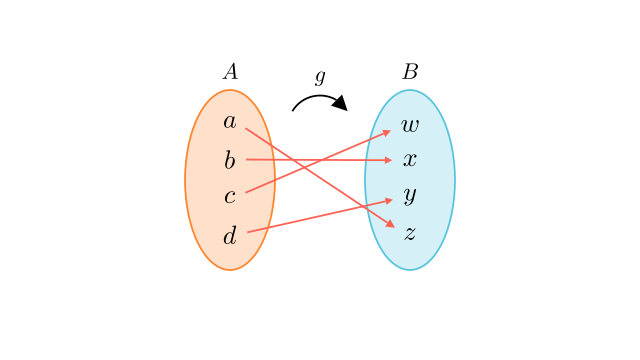

In [15]:
%%generate_image equinumerous-sets_g FunctionDiagram

A_FONT_SIZE = 56  # TeX font size
A_COLOUR = ORANGE
B_FONT_SIZE = 56
B_COLOUR = BLUE

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a.shift(2 * LEFT)
        
        ellipse_b = Ellipse(width=2, height=4, color=B_COLOUR)
        ellipse_b.set_fill(B_COLOUR, opacity=0.25)
        ellipse_b.shift(2 * RIGHT)

        self.add(ellipse_a, ellipse_b)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)

        self.add(label_a, label_b)

        # Add function label
        f_label = MathTex("g", color=BLACK).move_to(2.25*UP)
        f_label.add(
            CurvedArrow(
                f_label.get_left() + LEFT * 0.5,
                f_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        self.add(f_label)

        # Create elements for sets
        elements_a = ["a", "b", "c", "d"]
        elements_b = ["w", "x", "y", "z"]

        elements_a = [MathTex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [MathTex(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.5).move_to(ellipse_b)

        self.add(elements_a, elements_b)
        
        # Create arrows
        arrow_links = [
            (0,3),
            (1,1),
            (2,0),
            (3,2)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))

### Non-Equinumerous Sets

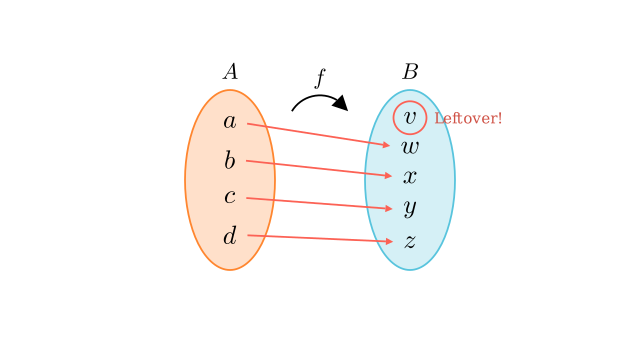

In [16]:
%%generate_image non-equinumerous-sets FunctionDiagram

A_FONT_SIZE = 56  # TeX font size
A_COLOUR = ORANGE
B_FONT_SIZE = 56
B_COLOUR = BLUE
LEFTOVER_FONT_SIZE = 24  # Normal font size

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a.shift(2 * LEFT)
        
        ellipse_b = Ellipse(width=2, height=4, color=B_COLOUR)
        ellipse_b.set_fill(B_COLOUR, opacity=0.25)
        ellipse_b.shift(2 * RIGHT)

        self.add(ellipse_a, ellipse_b)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)

        self.add(label_a, label_b)

        # Add function label
        f_label = MathTex("f", color=BLACK).move_to(2.25*UP)
        f_label.add(
            CurvedArrow(
                f_label.get_left() + LEFT * 0.5,
                f_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        self.add(f_label)

        # Create elements for sets
        elements_a = ["a", "b", "c", "d"]
        elements_b = ["v", "w", "x", "y", "z"]

        elements_a = [MathTex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [MathTex(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.4).move_to(ellipse_b)

        self.add(elements_a, elements_b)
        
        # Create arrows
        arrow_links = [(i,i+1) for i in range(4)]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))

        # Emphasise the leftover element
        leftover_circle = Circle(color=RED).surround(elements_b[0], buffer_factor=2.0)
        leftover_label = Text("Leftover!", color=RED_E, font_size=LEFTOVER_FONT_SIZE)
        leftover_label.next_to(leftover_circle, 0.75*RIGHT)
        
        self.add(leftover_circle, leftover_label)

### Cantor-Schröder-Bernstein

#### Setup

Common constants.

In [17]:
CIRCLE_COLOUR = WHITE
CIRCLE_OUTLINE = BLACK
CIRCLE_OPACITY = 1.0

SQUARE_COLOUR = GRAY
SQUARE_OUTLINE = BLACK
SQUARE_OPACITY = 0.3

Helper function to create the nested shapes.

In [18]:
def create_nested_shapes(
    initial_scale: float = 7.5,
    buff: float = 0.25,
    size_tolerance: float = 1e-5,
    first_shape: str = "square"
) -> VGroup:
    # Create the initial shapes
    if first_shape == "square":
        square = Square(side_length=1)
        circle = Circle(radius=0.5)
    else:
        circle = Circle(radius=0.5)
        square = Square(side_length=np.sqrt(2)/2)

    square.set_color(SQUARE_OUTLINE)
    square.set_fill(color=SQUARE_COLOUR, opacity=SQUARE_OPACITY)
    circle.set_color(CIRCLE_OUTLINE)
    circle.set_fill(color=CIRCLE_COLOUR, opacity=CIRCLE_OPACITY)
        
    initial_objects = [square, circle] if first_shape == "square" else [circle, square]
    initial_objects = VGroup(*initial_objects)

    # Repeatedly shrink the objects until tolerance is exceeded
    all_objects = []
    scale = initial_scale
    depth = 1
    while scale > size_tolerance:
        objects = initial_objects.copy()
        objects[0].scale(scale)
        objects[1].scale(scale-(buff/depth))

        scale = (scale-2*(buff/depth)) / np.sqrt(2)
        depth += 1
        all_objects.append(objects)

    # Return all the objects
    return VGroup(*all_objects)

#### Scenes

Create overarching class that generates the diagram in stages.

In [19]:
INITIAL_SCALE = 5.5

FONT_SIZE = 56  # TeX font size
FONT_SIZE_DECAY = 0.75

ARROW_STROKE_WIDTH = 4
ARROW_TIP_SIZE = 0.2
ARROW_COLOUR = BLACK

class CSBDiagram(Scene):
    # HELPER METHODS
    def _add_func_labels(self):
        f_label = MathTex("f", color=BLACK).move_to(3.5*UP + 0.5*RIGHT)
        f_label.add(
            CurvedArrow(
                f_label.get_left() + LEFT * 0.5,
                f_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )
        
        g_label = MathTex("g", color=BLACK).move_to(3.75*DOWN + 0.5*RIGHT)
        g_label.add(
            CurvedArrow(
                g_label.get_right() + RIGHT * 0.5,
                g_label.get_left() + LEFT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(UP * 0.35)
        )

        self.add(f_label, g_label)

    def _add_set_labels(self, set_a: Mobject, set_b: Mobject):
        label_a = MathTex("A", font_size=FONT_SIZE, color=BLACK)
        label_a.next_to(set_a, 0.5*(UP+LEFT))
        label_a.shift(0.5*RIGHT)
        
        label_b = MathTex("B", font_size=FONT_SIZE, color=BLACK)
        label_b.next_to(set_b, 0.5*(UP+RIGHT))
        label_b.shift(0.8 * (DOWN+LEFT))

        self.add(label_a, label_b)

    # MAIN STAGES
    def _stage_0(self):
        # Just draw the outer shapes
        set_a = Square(side_length=1).scale(INITIAL_SCALE)
        set_b = Circle(radius=0.5).scale(INITIAL_SCALE)

        set_a.set_color(SQUARE_OUTLINE)
        set_a.set_fill(color=SQUARE_COLOUR, opacity=SQUARE_OPACITY)
        set_b.set_color(CIRCLE_OUTLINE)
        set_b.set_fill(color=CIRCLE_COLOUR, opacity=CIRCLE_OPACITY)

        set_a.move_to(3.5*LEFT)
        set_b.move_to(3.5*RIGHT)
        self.add(set_a, set_b)

        # Draw the two function labels
        self._add_func_labels()
        
        # Add labels to the sets
        self._add_set_labels(set_a, set_b)
        
    def _stage_1(self, add_func_labels: bool = True):
        # Create the two nested sets
        set_a = create_nested_shapes(initial_scale=INITIAL_SCALE, first_shape="square")
        set_b = create_nested_shapes(initial_scale=INITIAL_SCALE, first_shape="circle")

        set_a.move_to(3.5*LEFT)
        set_b.move_to(3.5*RIGHT)
        self.add(set_a, set_b)

        # Draw the two function labels
        if add_func_labels:
            self._add_func_labels()
        
        # Add labels to the sets
        self._add_set_labels(set_a, set_b)

        return set_a, set_b

    def _stage_2(self, set_a: VGroup, set_b: VGroup):  # Adding nested labels
        # SET A
        # First nested circle
        label = MathTex(r"g(B)", font_size=FONT_SIZE * FONT_SIZE_DECAY, color=BLACK)
        label.next_to(set_a[0][1], 0.5*(UP+RIGHT))
        label.rotate(-np.pi / 4)
        label.shift((DOWN+LEFT))
        self.add(label)

        # Inner nested square
        label = MathTex(r"(g \circ f)(A)", font_size=FONT_SIZE * FONT_SIZE_DECAY**2, color=BLACK)
        label.next_to(set_a[1][0], UP)
        label.shift(0.2*DOWN)
        self.add(label)

        # Inner nested circle
        label = MathTex(r"(g \circ f \circ g)(B)", font_size=FONT_SIZE * FONT_SIZE_DECAY**3, color=BLACK)
        label.next_to(set_a[1][1], 0.5*(UP+RIGHT))
        label.rotate(-np.pi / 4)
        label.shift(0.9*(DOWN+LEFT) + 0.1*(UP+LEFT))
        self.add(label)

        # Inner inner nested square
        label = MathTex(r"(g \circ f \circ g \circ f)(A)", font_size=FONT_SIZE * FONT_SIZE_DECAY**4, color=BLACK)
        label.next_to(set_a[2][0], UP)
        label.shift(0.2*DOWN)
        self.add(label)

        # Inner inner nested circle
        label = MathTex(r"(g \circ f \circ g \circ f \circ g)(B)", font_size=FONT_SIZE * FONT_SIZE_DECAY**5, color=BLACK)
        label.next_to(set_a[2][1], 0.5*(UP+RIGHT))
        label.rotate(-np.pi / 4)
        label.shift(0.7*(DOWN+LEFT))
        self.add(label)

        # SET B
        # First nested square
        label = MathTex(r"f(A)", font_size=FONT_SIZE * FONT_SIZE_DECAY, color=BLACK)
        label.next_to(set_b[0][1], UP)
        label.shift(0.2*DOWN)
        self.add(label)

        # Inner nested circle
        label = MathTex(r"(f \circ g)(B)", font_size=FONT_SIZE * FONT_SIZE_DECAY**2, color=BLACK)
        label.next_to(set_b[1][1], 0.5*(UP+RIGHT))
        label.rotate(-np.pi / 4)
        label.shift(0.35*(DOWN+LEFT) + 0.1*(UP+LEFT))
        self.add(label)

        # Inner nested square
        label = MathTex(r"(f \circ g \circ f)(A)", font_size=FONT_SIZE * FONT_SIZE_DECAY**3, color=BLACK)
        label.next_to(set_b[2][0], UP)
        label.shift(0.15*DOWN)
        self.add(label)

        # Inner inner nested circle
        label = MathTex(r"(f \circ g \circ f \circ g)(B)", font_size=FONT_SIZE * FONT_SIZE_DECAY**4, color=BLACK)
        label.next_to(set_b[2][1], 0.5*(UP+RIGHT))
        label.rotate(-np.pi / 4)
        label.shift(0.4*(DOWN+LEFT))
        self.add(label)

    def _stage_3(self, set_a: VGroup, set_b: VGroup):  # Adding mapping labels
        # First circle map
        arrow = Line(
            set_a[0][1].get_corner(UP+RIGHT) + 0.4*DOWN + 2.25*LEFT,
            set_b[0][0].get_corner(UP+LEFT) + 0.45*DOWN + 2.5*RIGHT,
            stroke_width=ARROW_STROKE_WIDTH,
            color=ARROW_COLOUR
        )
        arrow.add_tip(tip_width=ARROW_TIP_SIZE, tip_length=ARROW_TIP_SIZE)
        arrow.add(
            MathTex(
                "g^{-1}", font_size=FONT_SIZE*0.75, color=BLACK
            ).next_to(arrow, UP).shift(0.3*DOWN)
        )
        self.add(arrow)

        # Second circle map
        arrow = Line(
            set_a[1][1].get_corner(UP+RIGHT) + 0.3*DOWN + 1.3*LEFT,
            set_b[1][0].get_corner(UP+LEFT) + 0.3*DOWN + 1.55*RIGHT,
            stroke_width=ARROW_STROKE_WIDTH,
            color=ARROW_COLOUR
        )
        arrow.add_tip(tip_width=ARROW_TIP_SIZE, tip_length=ARROW_TIP_SIZE)
        arrow.add(
            MathTex(
                "g^{-1}", font_size=FONT_SIZE*0.75, color=BLACK
            ).next_to(arrow, UP).shift(0.3*DOWN)
        )
        self.add(arrow)

        # Third circle map
        arrow = Line(
            set_a[2][1].get_corner(RIGHT) + 0.35*UP + 0.25*LEFT,
            set_b[2][0].get_corner(LEFT) + 0.35*UP + 0.25*RIGHT,
            stroke_width=ARROW_STROKE_WIDTH,
            color=ARROW_COLOUR
        )
        arrow.add_tip(tip_width=ARROW_TIP_SIZE, tip_length=ARROW_TIP_SIZE)
        arrow.add(
            MathTex(
                "g^{-1}", font_size=FONT_SIZE*0.75, color=BLACK
            ).next_to(arrow, UP).shift(0.275*DOWN)
        )
        self.add(arrow)

        # First square map
        arrow = DashedLine(
            set_a[0][0].get_corner(DOWN+RIGHT) + 1.2*UP + 0.4*LEFT,
            set_b[0][1].get_corner(DOWN+LEFT) + 0.3*UP + 0.5*RIGHT,
            stroke_width=ARROW_STROKE_WIDTH,
            color=ARROW_COLOUR
        )
        arrow.add_tip(tip_width=ARROW_TIP_SIZE, tip_length=ARROW_TIP_SIZE)
        arrow.add(
            MathTex(
                "f", font_size=FONT_SIZE*0.75, color=BLACK
            ).next_to(arrow, UP).shift(0.3*DOWN + 0.2*LEFT)
        )
        self.add(arrow)

        # Second square map
        arrow = DashedLine(
            set_a[1][0].get_corner(DOWN+RIGHT) + 0.85*UP + 0.125*LEFT,
            set_b[1][1].get_corner(DOWN+LEFT) + 0.3*UP + 0.25*RIGHT,
            stroke_width=ARROW_STROKE_WIDTH,
            color=ARROW_COLOUR
        )
        arrow.add_tip(tip_width=ARROW_TIP_SIZE, tip_length=ARROW_TIP_SIZE)
        arrow.add(
            MathTex(
                "f", font_size=FONT_SIZE*0.75, color=BLACK
            ).next_to(arrow, UP).shift(0.3*DOWN + 0.2*LEFT)
        )
        self.add(arrow)

Original diagram with no nesting.

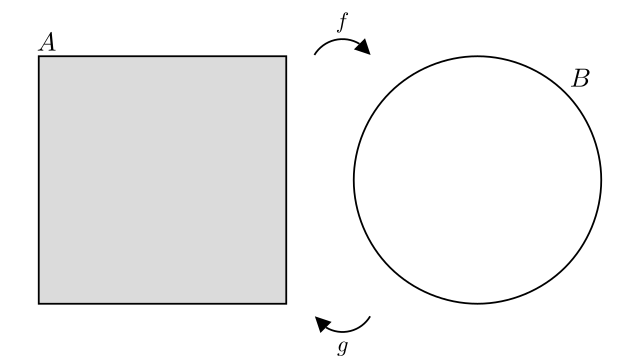

In [20]:
%%generate_image csb_0 MyCSBDiagram

class MyCSBDiagram(CSBDiagram):
    def construct(self):
        self._stage_0()

Diagram with nesting but no function labels.

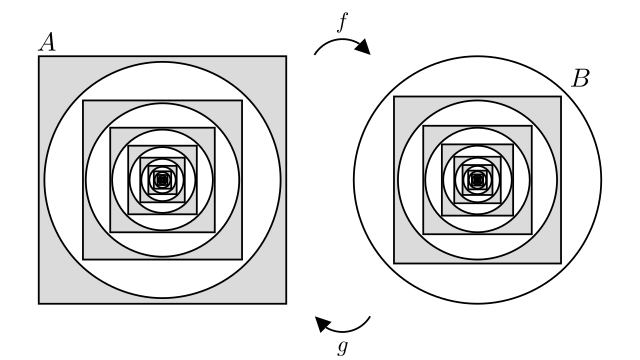

In [21]:
%%generate_image csb_1 MyCSBDiagram

class MyCSBDiagram(CSBDiagram):
    def construct(self):
        self._stage_1()

Diagram with nesting and function labels, but no example point.

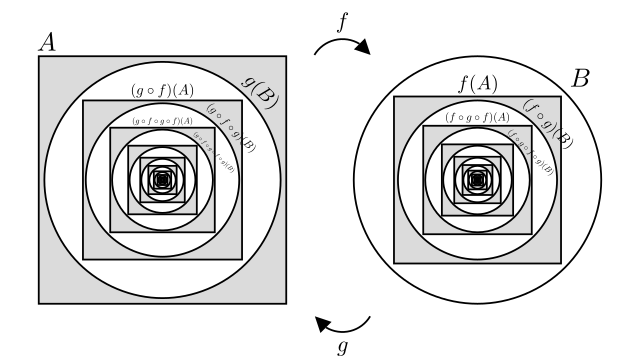

In [22]:
%%generate_image csb_2 MyCSBDiagram

class MyCSBDiagram(CSBDiagram):
    def construct(self):
        set_a, set_b = self._stage_1()
        self._stage_2(set_a, set_b)

Diagram with suggestive mapping from $A$ to $B$.

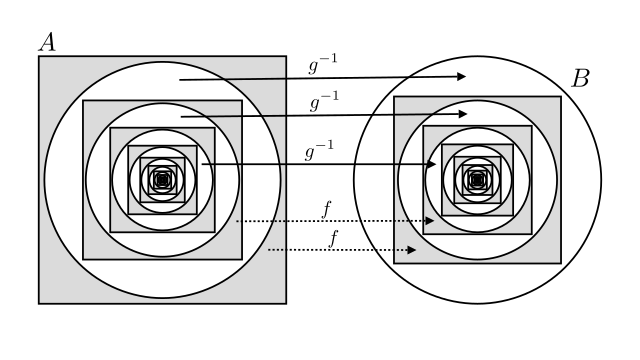

In [23]:
%%generate_image csb_3 MyCSBDiagram

class MyCSBDiagram(CSBDiagram):
    def construct(self):
        set_a, set_b = self._stage_1(add_func_labels=False)
        self._stage_3(set_a, set_b)